In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/diabetic_data.csv")

df.shape

#101,766 rows / 50 columns

(101766, 50)

In [ ]:
missing = df.isnull().mean()*100
missing.sort_values(ascending=False)

(df == '?').sum()

#Some missing values, but none that are essential to the project
#Well over 1,000 data entries without any missing information

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [16]:
df["readmitted_30days"] = df["readmitted"].map({
"<30": "Yes",
">30": "No",
"NO": "No"
})

#Since we are concerned about readmissions within 30 days, converting the dataset to binary Yes/No instead of <30, >30, or no makes sense

Text(0, 0.5, 'Count')

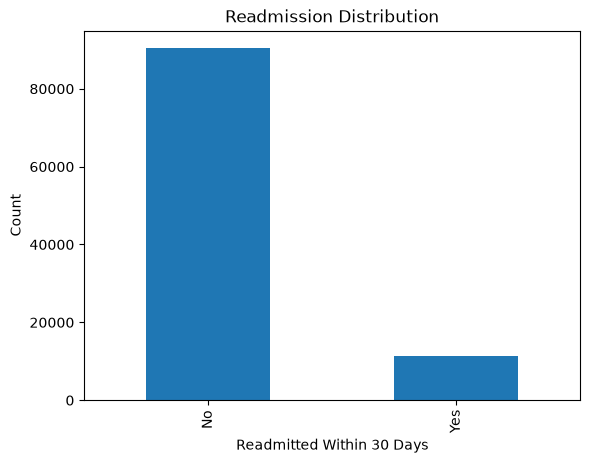

In [22]:
df["readmitted_30days"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Count")

In [26]:
class_balance = (
df["readmitted_30days"]
.value_counts()
.reset_index()
)

class_balance.columns = ["Class", "Count"]

class_balance["Percent"] = (
class_balance["Count"] /
class_balance["Count"].sum() * 100
).round(2)

print(class_balance)

# Readmitted within 30 days?
# 90,409 No
# 11,357 Yes
# Approximately 1 in 10 patients are re-admitted tot he hospital within 30 days

  Class  Count  Percent
0    No  90409    88.84
1   Yes  11357    11.16


In [28]:
class_balance.to_csv("../data/class_balance.csv", index=False)

In [31]:
df.dtypes

missing_percent = (
df.isnull().mean() * 100
).round(2)

In [34]:
feature_inventory = pd.DataFrame({
"Feature": df.columns,
"Data Type": df.dtypes.astype(str),
"Percent Missing": (
df.isnull().mean() * 100
).round(2)
}).reset_index(drop=True)

feature_inventory

,Feature,Data Type,Percent Missing
0,encounter_id,int64,0.00
1,patient_nbr,int64,0.00
2,race,str,0.00
3,gender,str,0.00
4,age,str,0.00
5,weight,str,0.00
6,admission_type_id,int64,0.00
7,discharge_disposition_id,int64,0.00
8,admission_source_id,int64,0.00
9,time_in_hospital,int64,0.00


In [39]:
descriptions = {
"encounter_id": "Unique identifier for hospital encounter",
"patient_nbr": "Unique identifier for patient",
"race": "Patient race or ethnicity",
"gender": "Patient gender",
"age": "Patient age group",
"weight": "Patient weight range",
"admission_type_id": "Type of admission to the hospital",
"discharge_disposition_id": "Patient discharge disposition",
"admission_source_id": "Source of hospital admission",
"time_in_hospital": "Length of hospital stay in days",
"payer_code": "Insurance or payer classification",
"medical_specialty": "Specialty of the attending physician",
"num_lab_procedures": "Number of laboratory procedures performed",
"num_procedures": "Number of non-laboratory procedures performed",
"num_medications": "Number of medications administered",
"number_outpatient": "Number of outpatient visits in the previous year",
"number_emergency": "Number of emergency department visits in the previous year",
"number_inpatient": "Number of inpatient admissions in the previous year",
"diag_1": "Primary diagnosis code",
"diag_2": "Secondary diagnosis code",
"diag_3": "Tertiary diagnosis code",
"number_diagnoses": "Total number of diagnoses recorded",
"max_glu_serum": "Maximum serum glucose test result",
"A1Cresult": "Most recent hemoglobin A1C test result",
"metformin": "Whether metformin was prescribed or changed",
"repaglinide": "Whether repaglinide was prescribed or changed",
"nateglinide": "Whether nateglinide was prescribed or changed",
"chlorpropamide": "Whether chlorpropamide was prescribed or changed",
"glimepiride": "Whether glimepiride was prescribed or changed",
"acetohexamide": "Whether acetohexamide was prescribed or changed",
"glipizide": "Whether glipizide was prescribed or changed",
"glyburide": "Whether glyburide was prescribed or changed",
"tolbutamide": "Whether tolbutamide was prescribed or changed",
"pioglitazone": "Whether pioglitazone was prescribed or changed",
"rosiglitazone": "Whether rosiglitazone was prescribed or changed",
"acarbose": "Whether acarbose was prescribed or changed",
"miglitol": "Whether miglitol was prescribed or changed",
"troglitazone": "Whether troglitazone was prescribed or changed",
"tolazamide": "Whether tolazamide was prescribed or changed",
"examide": "Whether examide was prescribed or changed",
"citoglipton": "Whether citoglipton was prescribed or changed",
"insulin": "Whether insulin was prescribed or changed",
"glyburide-metformin": "Whether glyburide-metformin combination was prescribed or changed",
"glipizide-metformin": "Whether glipizide-metformin combination was prescribed or changed",
"glimepiride-pioglitazone": "Whether glimepiride-pioglitazone combination was prescribed or changed",
"metformin-rosiglitazone": "Whether metformin-rosiglitazone combination was prescribed or changed",
"metformin-pioglitazone": "Whether metformin-pioglitazone combination was prescribed or changed",
"change": "Indicates whether diabetes medications changed during the encounter",
"diabetesMed": "Indicates whether any diabetes medication was prescribed",
"readmitted": "Original hospital readmission category",
"readmitted_30days": "Target variable indicating readmission within 30 days"
}

feature_inventory["Description"] = (
feature_inventory["Feature"]
.map(descriptions)
)

In [46]:
(df == "?").sum()

df = df.replace("?", np.nan)

feature_inventory = pd.DataFrame({
"Feature": df.columns,
"Data Type": df.dtypes.astype(str),
"Percent Missing": (
df.isnull().mean() * 100
).round(2)
})

In [ ]:
feature_inventory.to_csv(
"../data/feature_inventory.csv",
index=False
)